# **Bias Detection**

Agora que temos um modelo de classificação estabelecido (Gradient Boosting), realizamos uma análise de viés com o objetivo de verificar se a classificação apresenta disparidades entre diferentes grupos socioeconômicos, especificamente em relação à renda e escolaridade.

Para a análise de viés, utilizamos as previsões geradas pelo modelo no conjunto de teste, previamente utilizado na avaliação de desempenho. Nesta etapa, o foco não está na acurácia do modelo, mas sim em investigar se o modelo apresenta indícios de injustiça algorítmica, isto é, se tende a penalizar desproporcionalmente determinados grupos presentes na base de dados.

In [4]:
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sys.path.append('../..')

from data_engine import BankLoanPipeline
from sklearn.ensemble import GradientBoostingClassifier

In [5]:
# carregar dados
df = pd.read_csv('../../data/bankloans.csv')

# reconstruir split (só pra pegar índice)
pipeline = BankLoanPipeline()
X_train, X_test, y_train, y_test = pipeline.process(df)

# df com colunas originais
df_test = df.loc[y_test.index].copy()

# carregar dados reais usados no modelo
X_train_real = np.load('../../data/X_train.npy')
X_test_real = np.load('../../data/X_test.npy')
y_train_real = np.load('../../data/Y_train.npy')
y_test_real = np.load('../../data/Y_test.npy')

# treinar modelo
model = GradientBoostingClassifier()
model.fit(X_train_real, y_train_real)

# previsão
y_pred = model.predict(X_test_real)

# adicionar no df
df_test['y_pred'] = y_pred
df_test['y_true'] = y_test_real

------------------------------
LOG DE BALANCEAMENTO (Under-Sampling)
Antes:  {0.0: 414, 1.0: 146}
Depois: {0.0: 146, 1.0: 146}
------------------------------


## **Visualizações**

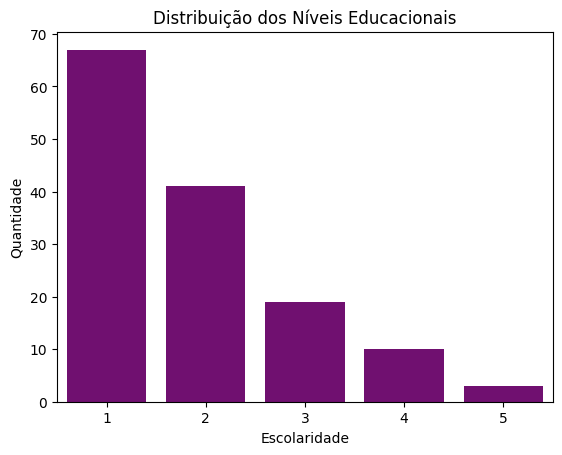

In [6]:
#verificando os niveis educacionais
sns.countplot(data=df_test, x='ed', color='purple')
plt.title('Distribuição dos Níveis Educacionais')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade')
plt.show()

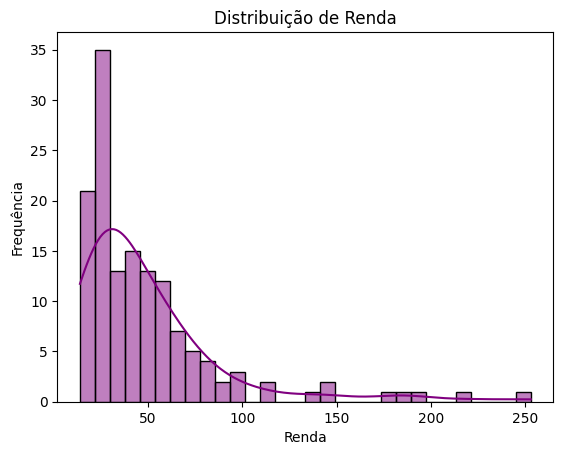

In [7]:
#analisando distribuição da renda
sns.histplot(data=df_test, x='income', bins=30, kde=True, color='purple')
plt.title('Distribuição de Renda')
plt.xlabel('Renda')
plt.ylabel('Frequência')
plt.show()

## **Formando Grupos**
Por meio dos gáficos apresentados, notamos que a maior parte tem o nível mais baixo de escolaridade e renda menor. Dado siso, queremos descobrir se o modelo está enviesado para algum lado. Para isso dividiremos nosso dados em grupos, para posterior análise.

In [8]:
#criando grupos de renda
df_test['income_group'] = pd.qcut(
    df_test['income'],
    q=3,
    labels=['Baixa', 'Média', 'Alta']
)

In [9]:
df_test['income_group'].unique()

['Baixa', 'Alta', 'Média']
Categories (3, str): ['Baixa' < 'Média' < 'Alta']

In [10]:
df_test['ed'].unique()

array([1, 2, 4, 3, 5])

## **Porcentagem Clientes Não Confiáveis Por Grupo**
Com os grupos feitos, queremos observar se houve diferença entre as porcentagens de inadimplmentes por grupo, considerando os resultados previstos pelo modelo ('y_pred') e os reais ('y_true').

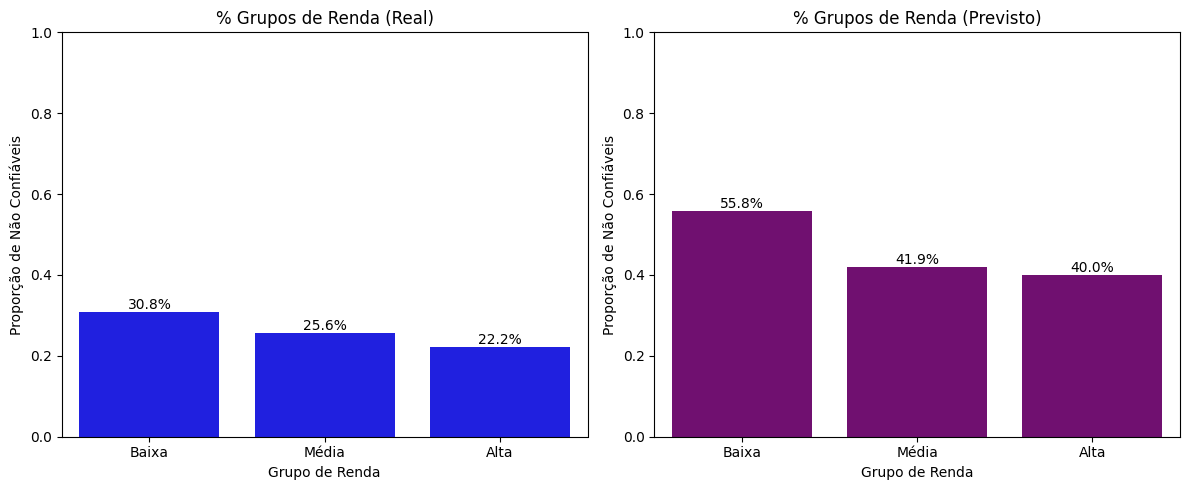

In [11]:
# calcular dados
perc_pred = df_test.groupby('income_group')['y_pred'].mean().reset_index()
perc_true = df_test.groupby('income_group')['y_true'].mean().reset_index()

# criar figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Gráfico real
sns.barplot(x='income_group', y='y_true', data=perc_true, ax=axes[0], color='blue')

for i, v in enumerate(perc_true['y_true']):
    axes[0].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[0].set_title('% Grupos de Renda (Real)')
axes[0].set_ylabel('Proporção de Não Confiáveis')
axes[0].set_xlabel('Grupo de Renda')
axes[0].set_ylim(0,1)

# 🔹 Gráfico previsto
sns.barplot(x='income_group', y='y_pred', data=perc_pred, ax=axes[1], color='purple')

for i, v in enumerate(perc_pred['y_pred']):
    axes[1].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[1].set_title('% Grupos de Renda (Previsto)')
axes[1].set_ylabel('Proporção de Não Confiáveis')
axes[1].set_xlabel('Grupo de Renda')
axes[1].set_ylim(0,1)


plt.tight_layout()
plt.show()

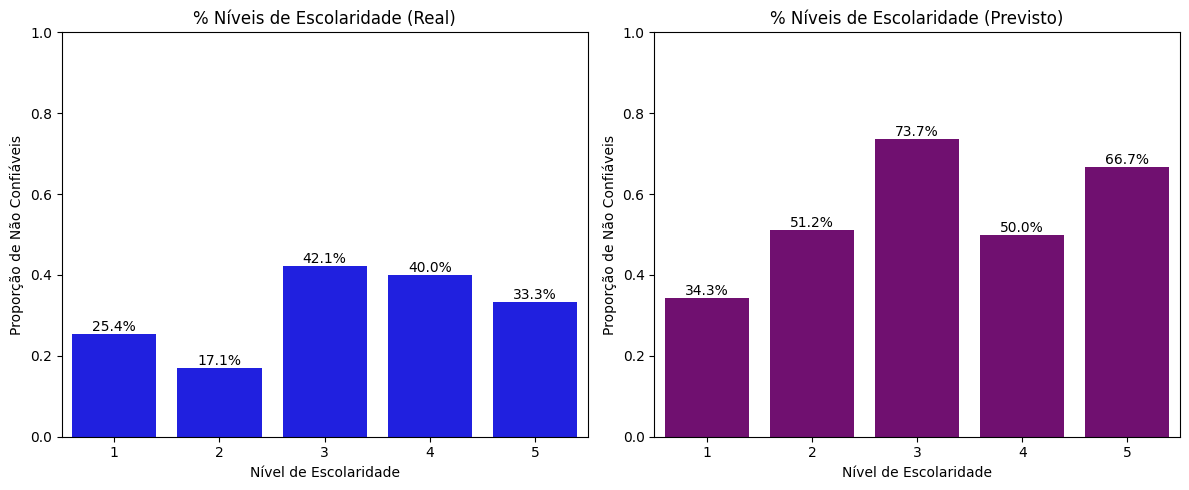

In [12]:
# calcular dados
perc_pred = df_test.groupby('ed')['y_pred'].mean().reset_index()
perc_true = df_test.groupby('ed')['y_true'].mean().reset_index()

# criar figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Gráfico real
sns.barplot(x='ed', y='y_true', data=perc_true, ax=axes[0], color='blue')

for i, v in enumerate(perc_true['y_true']):
    axes[0].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[0].set_title('% Níveis de Escolaridade (Real)')
axes[0].set_ylabel('Proporção de Não Confiáveis')
axes[0].set_xlabel('Nível de Escolaridade')
axes[0].set_ylim(0,1)

# 🔹 Gráfico previsto
sns.barplot(x='ed', y='y_pred', data=perc_pred, ax=axes[1], color='purple')

for i, v in enumerate(perc_pred['y_pred']):
    axes[1].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[1].set_title('% Níveis de Escolaridade (Previsto)')
axes[1].set_ylabel('Proporção de Não Confiáveis')
axes[1].set_xlabel('Nível de Escolaridade')
axes[1].set_ylim(0,1)


plt.tight_layout()
plt.show()

A análise comparativa entre os valores reais e previstos revela que o modelo não apenas reproduz as diferenças existentes nos dados, mas também as amplifica.

* No caso da renda, observa-se que o modelo eleva a proporção de clientes classificados como não confiáveis em todos os grupos. Embora o aumento seja mais expressivo em termos absolutos para o grupo de baixa renda, o crescimento ocorre de forma generalizada, indicando que o modelo tende a superestimar o risco de inadimplência independentemente do grupo analisado.

* Para a variável de escolaridade, a distorção é ainda mais evidente, com determinados níveis apresentando taxas previstas de inadimplência muito superiores às observadas nos dados reais.

Esses resultados sugerem que o modelo pode estar **introduzindo** ou **intensificando vieses**, penalizando desproporcionalmente certos grupos.

In [21]:
#função para calcular a taxa de falsos positivos (clientes confiáveis que o modelo julgou como n confiáveis)
def calcular_fpr(df):
    cm = confusion_matrix(df['y_true'], df['y_pred'])
    
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    
    return fpr

Após observar que o modelo aumentou a proporção de clientes classificados como não confiáveis, analisamos a **taxa de falsos positivos (FPR)** para entender a origem desse comportamento. Essa métrica permite identificar a proporção de clientes confiáveis que foram incorretamente classificados como não confiáveis. 

## **Matriz de Confusão - Grupo de Renda**

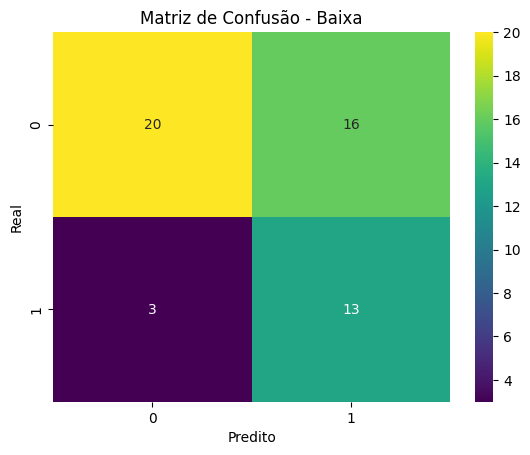

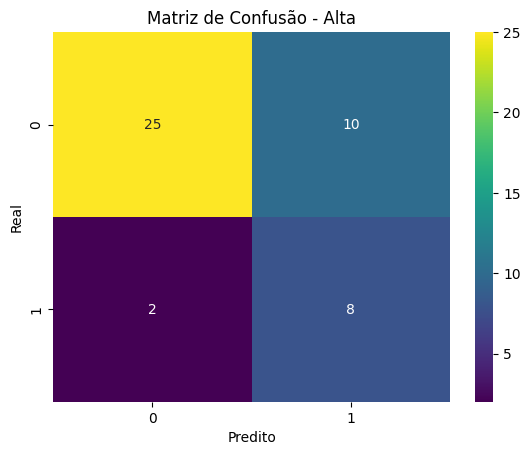

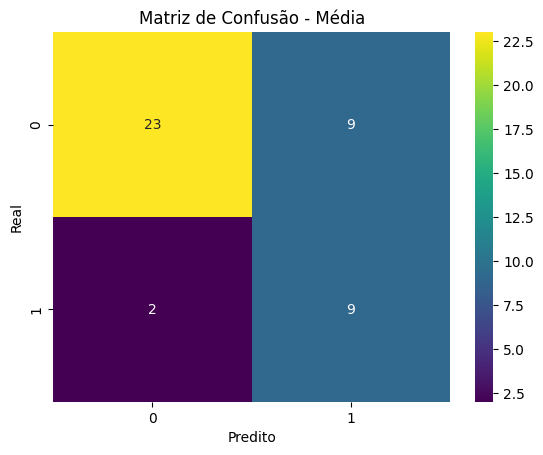

In [18]:
for group in df_test['income_group'].unique():
    df_g = df_test[df_test['income_group'] == group]
    
    cm = confusion_matrix(df_g['y_true'], df_g['y_pred'])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Matriz de Confusão - {group}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

In [22]:
for group in df_test['income_group'].unique():
    df_g = df_test[df_test['income_group'] == group]
    
    fpr = calcular_fpr(df_g)
    
    print(f"{group}: FPR = {fpr:.2%}")

Baixa: FPR = 44.44%
Alta: FPR = 28.57%
Média: FPR = 28.12%


In [34]:
df_test[df_test['ed'] == 5]

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,y_pred,y_true,income_group
456,37,5,9,16,177,5.9,0.887655,9.555345,0.0,1.0,0.0,Alta
384,52,5,9,0,70,9.4,1.329160,5.250840,1.0,1.0,1.0,Alta
502,42,5,6,23,190,7.8,3.156660,11.663340,0.0,0.0,0.0,Alta


## **Matriz de Confusão - Nível Educacional**

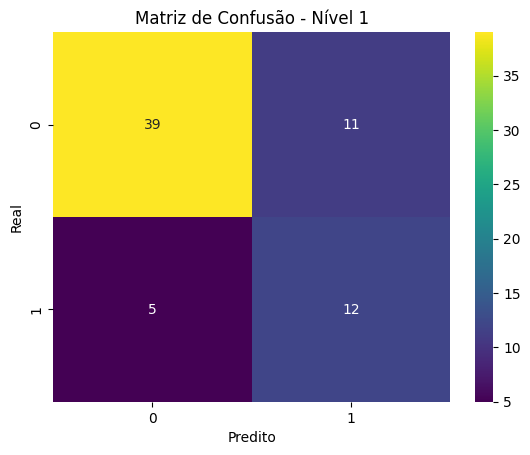

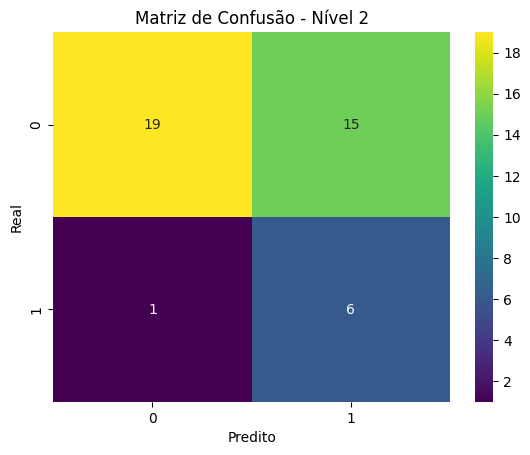

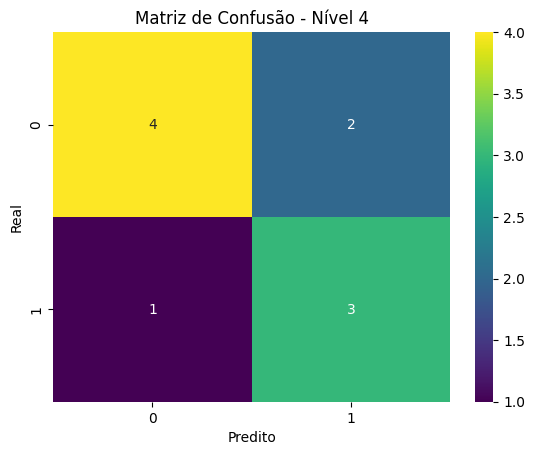

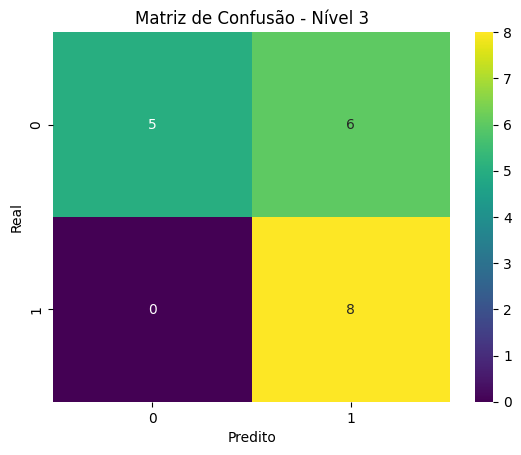

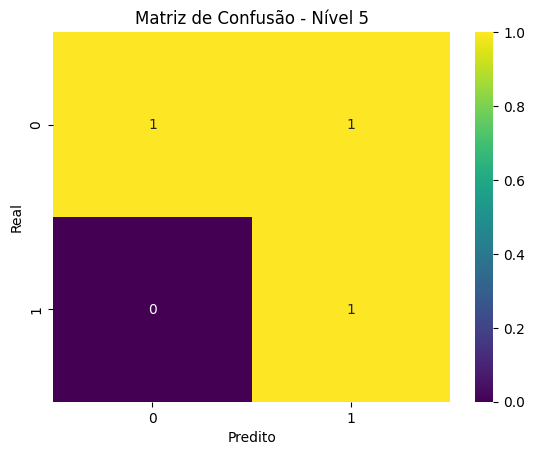

In [15]:
for group in df_test['ed'].unique():
    df_g = df_test[df_test['ed'] == group]
    
    cm = confusion_matrix(df_g['y_true'], df_g['y_pred'])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Matriz de Confusão - Nível {group}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

In [29]:
df_test = df_test.sort_values(by='ed')

In [30]:
for group in df_test['ed'].unique():
    df_g = df_test[df_test['ed'] == group]
    
    fpr = calcular_fpr(df_g)
    
    print(f"{group}: FPR = {fpr:.2%}")

1: FPR = 22.00%
2: FPR = 44.12%
3: FPR = 54.55%
4: FPR = 33.33%
5: FPR = 50.00%


## **Conclusão**

Diante dos resultados, conclui-se que o modelo apresenta evidências de viés em relação à variável de renda, penalizando de forma mais intensa clientes de baixa renda. Já na parte da escolaridade, apenas no grupo 2 obtivemos um resultado que pode ser traduzido como viés, usando a **FPR** para tal, visto que os outros grupos ou tem uma taxa menor ou contam com uma amostra muito pequena para avaliar tal parte.

Esse achado reforça a importância de incorporar análises de equidade no desenvolvimento de modelos preditivos, especialmente em contextos sensíveis como concessão de crédito.

Como possíveis próximos passos, seria interessante aplicar técnicas de mitigação de viés, como balanceamento de dados, ajuste de pesos ou utilização de métricas de fairness durante o treinamento, a fim de reduzir as disparidades identificadas e tornar o modelo mais justo e confiável.